# Character-Level Attention Maps

Clean visualization of attention maps per character position, comparing 0/4/8/16 register tokens.  
Layout inspired by **Fig. 5** in *"Beyond Memorization"* — uniform grid, one column per character.

In [1]:
import sys, json, math
from pathlib import Path
from types import SimpleNamespace
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, zoom

ROOT = Path('.').resolve()
if ROOT.name == 'notebook': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from models import HTRNet
from utils.preprocessing import load_image, preprocess

DEVICE = 'cpu'
EXP_DIR = ROOT / 'saved_models' / 'experiments'
IMG_H, IMG_W = 128, 1024
OUT_DIR = ROOT / 'outputs' / 'attention_maps'
OUT_DIR.mkdir(parents=True, exist_ok=True)

charset = list(np.load(str(EXP_DIR / 'classes.npy'), allow_pickle=True))
RUNS = {0: 'run_76', 4: 'run_84', 8: 'run_63', 16: 'run_71'}

print(f'Charset: {len(charset)} classes')

Charset: 79 classes


In [7]:
# ── Helpers ──

def load_model(run_id):
    d = EXP_DIR / run_id
    cfg = json.load(open(d / 'config.json'))
    m = HTRNet(SimpleNamespace(**cfg['arch']), len(charset) + 1)
    m.load_state_dict(torch.load(str(d / 'model.pt'), map_location=DEVICE, weights_only=False), strict=False)
    return m.to(DEVICE).eval()

def prep_image(path):
    img = load_image(str(path))
    img_proc = preprocess(img, (IMG_H, IMG_W))
    tensor = torch.from_numpy(img_proc).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
    return tensor, img_proc

def ctc_decode(logits):
    probs = torch.softmax(logits[:, 0, :], dim=-1)
    ids = probs.argmax(dim=-1).cpu().numpy()
    chars, peaks = [], []
    prev = -1
    for t, idx in enumerate(ids):
        if idx != 0 and idx != prev:
            ci = idx - 1
            if 0 <= ci < len(charset):
                chars.append(charset[ci])
                peaks.append(t)
        prev = idx
    return ''.join(chars).strip(), peaks

def tight_crop(img, pad=10):
    """
    Crop to tight bounding box of ink pixels.
    NOTE: images are INVERTED (0=white, ink=high values).
    Returns: cropped_img, (y0, y1, x0, x1)
    """
    col_ink = img.mean(axis=0)   # high where ink is
    row_ink = img.mean(axis=1)
    ct = col_ink.max() * 0.05
    rt = row_ink.max() * 0.05
    
    cc = np.where(col_ink > ct)[0]
    rr = np.where(row_ink > rt)[0]
    if len(cc) == 0 or len(rr) == 0:
        return img, (0, img.shape[0], 0, img.shape[1])
    
    x0 = max(0, cc[0] - pad)
    x1 = min(img.shape[1], cc[-1] + pad)
    y0 = max(0, rr[0] - pad)
    y1 = min(img.shape[0], rr[-1] + pad)
    return img[y0:y1, x0:x1], (y0, y1, x0, x1)

print('Helpers loaded.')

Helpers loaded.


Original: (128, 1024) → Cropped: (128, 172)
Crop box: rows [0:128], cols [2:174]
Removed 83% blank space


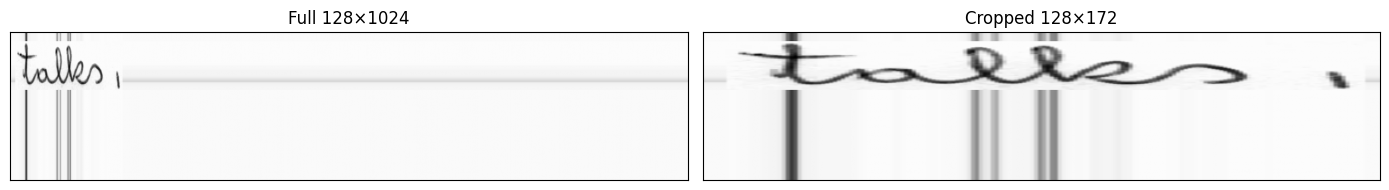

In [8]:
# ── Verify cropping works ──
tensor, img_proc = prep_image(ROOT / 'notebook' / 'sample_images' / 'a01-038-12.png')
img_crop, (y0, y1, x0, x1) = tight_crop(img_proc)
print(f'Original: {img_proc.shape} → Cropped: {img_crop.shape}')
print(f'Crop box: rows [{y0}:{y1}], cols [{x0}:{x1}]')
print(f'Removed {100*(1 - img_crop.size/img_proc.size):.0f}% blank space')

fig, axes = plt.subplots(1, 2, figsize=(14, 2))
axes[0].imshow(img_proc, cmap='gray_r', aspect='auto'); axes[0].set_title('Full 128×1024')
axes[1].imshow(img_crop, cmap='gray_r', aspect='auto'); axes[1].set_title(f'Cropped {img_crop.shape[0]}×{img_crop.shape[1]}')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Approach 1: Gradient Saliency — True 2D Character Maps

For each character, backprop from its CTC logit to the input pixels.  
This gives a genuine **2D heatmap** (H×W) showing which pixels drove that character's prediction.  
Unlike self-attention (which is 1D for our model), gradient saliency naturally produces spatial maps.

In [2]:
def compute_char_saliency(model, tensor, peak_t, class_idx):
    """Gradient saliency |∂logit[t,class] / ∂input| → 2D heatmap."""
    inp = tensor.clone().detach().requires_grad_(True)
    model.zero_grad()
    logits = model(inp)
    logits[peak_t, 0, class_idx].backward()
    grad = inp.grad[0, 0].abs().cpu().numpy()  # [H, W]
    # Smooth for cleaner visualization
    grad = gaussian_filter(grad, sigma=3)
    return grad


def make_char_grid_saliency(img_name, gt, register_configs, crop_box=None):
    """
    Paper Fig 5 style grid using gradient saliency.
    Rows = register configs, Cols = Input + characters.
    Returns the figure.
    """
    tensor, img_proc = prep_image(ROOT / 'notebook' / 'sample_images' / img_name)
    
    # Tight 2D crop
    img_crop, (y0, y1, x0, x1) = tight_crop(img_proc, pad=15)
    
    # First, get decoded text from 0-reg model to set columns
    first_nr = list(register_configs.keys())[0]
    mdl0 = load_model(register_configs[first_nr])
    with torch.no_grad():
        lg0 = mdl0(tensor)
    ref_text, _ = ctc_decode(lg0)
    del mdl0
    n_chars = len(ref_text)
    n_cols = n_chars + 1  # input + characters
    n_rows = len(register_configs)
    
    cell_w = max(1.8, 10.0 / n_cols)  # adapt cell width to #chars
    cell_h = cell_w * img_crop.shape[0] / img_crop.shape[1]  # keep aspect ratio
    cell_h = max(cell_h, 1.2)
    
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(cell_w * n_cols + 1.5, cell_h * n_rows + 1.5))
    if n_rows == 1: axes = axes[np.newaxis, :]
    
    for row, (nr, rid) in enumerate(sorted(register_configs.items())):
        model = load_model(rid)
        with torch.no_grad():
            logits = model(tensor)
        text, peaks = ctc_decode(logits)
        
        # Col 0: input
        ax = axes[row, 0]
        ax.imshow(img_crop, cmap='gray_r', aspect='auto')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_ylabel(f'{nr} reg', fontsize=12, fontweight='bold', labelpad=10)
        if row == 0:
            ax.set_title('Input', fontsize=11, fontweight='bold', pad=8)
        
        # Compute saliency for each character
        for ci in range(n_chars):
            ax = axes[row, ci + 1]
            
            if ci < len(peaks) and ci < len(text):
                ch = text[ci]
                t = peaks[ci]
                class_idx = charset.index(ch) + 1  # +1 for CTC blank
                
                sal = compute_char_saliency(model, tensor, t, class_idx)
                sal_crop = sal[y0:y1, x0:x1]
                
                # Normalize per-map
                s_min, s_max = sal_crop.min(), sal_crop.max()
                if s_max > s_min:
                    sal_norm = (sal_crop - s_min) / (s_max - s_min)
                else:
                    sal_norm = np.zeros_like(sal_crop)
                
                ax.imshow(img_crop, cmap='gray_r', aspect='auto', alpha=0.3)
                ax.imshow(sal_norm, cmap='inferno', aspect='auto', alpha=0.7, vmin=0, vmax=1)
            else:
                ax.imshow(np.zeros_like(img_crop), cmap='gray', aspect='auto')
            
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ch_label = ref_text[ci] if ci < len(ref_text) else ''
                ax.set_title(f'$A_{{c={ci+1}}}$ "{ch_label}"', fontsize=11, fontweight='bold', pad=8)
        
        del model
        print(f'  {nr:>2} reg: "{text}"')
    
    fig.suptitle(f'Character Saliency Maps — "{gt}"\n'
                 f'Gradient |∂logit/∂input| per character  ·  Rows = register configs',
                 fontsize=13, fontweight='bold', y=1.0)
    plt.subplots_adjust(wspace=0.04, hspace=0.12)
    return fig

print('Saliency grid function ready.')

Saliency grid function ready.


/home/hpc/iwi5/iwi5369h/HTR-Pipeline/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


   0 reg: "talks."
   4 reg: "talks."
   8 reg: "talks."
  16 reg: "talks."


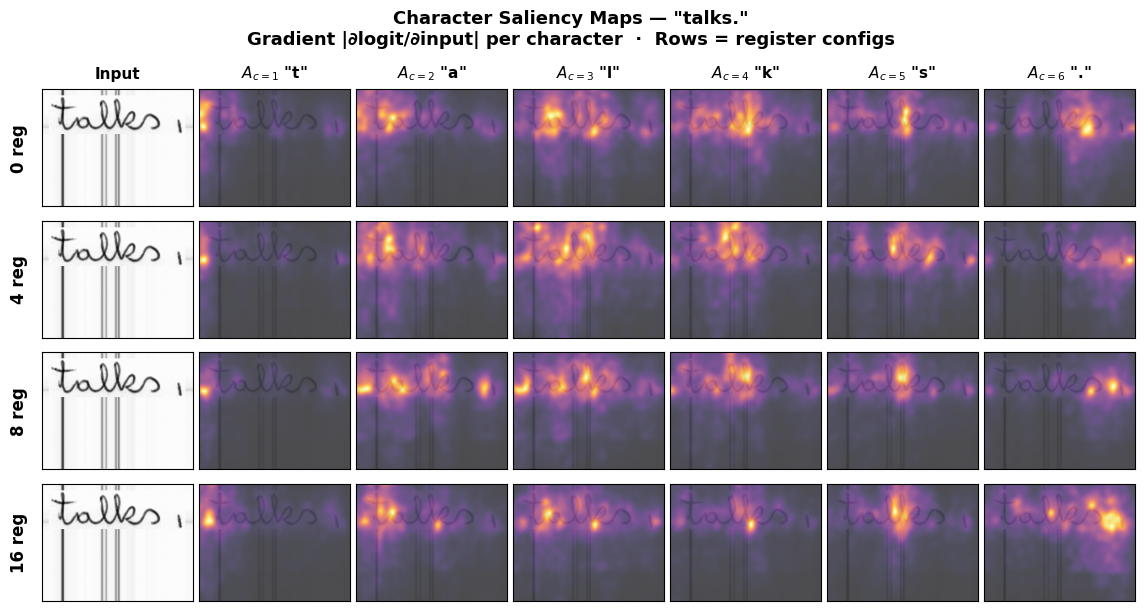

Saved: fig_saliency_talks.png


In [9]:
# ── Generate Fig 5 style: "talks." ──
fig = make_char_grid_saliency('a01-038-12.png', 'talks.', RUNS)
fig.savefig(str(OUT_DIR / 'fig_saliency_talks.png'), dpi=200, bbox_inches='tight')
fig.savefig(str(OUT_DIR / 'fig_saliency_talks.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved: fig_saliency_talks.png')

/home/hpc/iwi5/iwi5369h/HTR-Pipeline/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


   0 reg: "supporters."
   4 reg: "supporters."
   8 reg: "supporters."
  16 reg: "supporters."


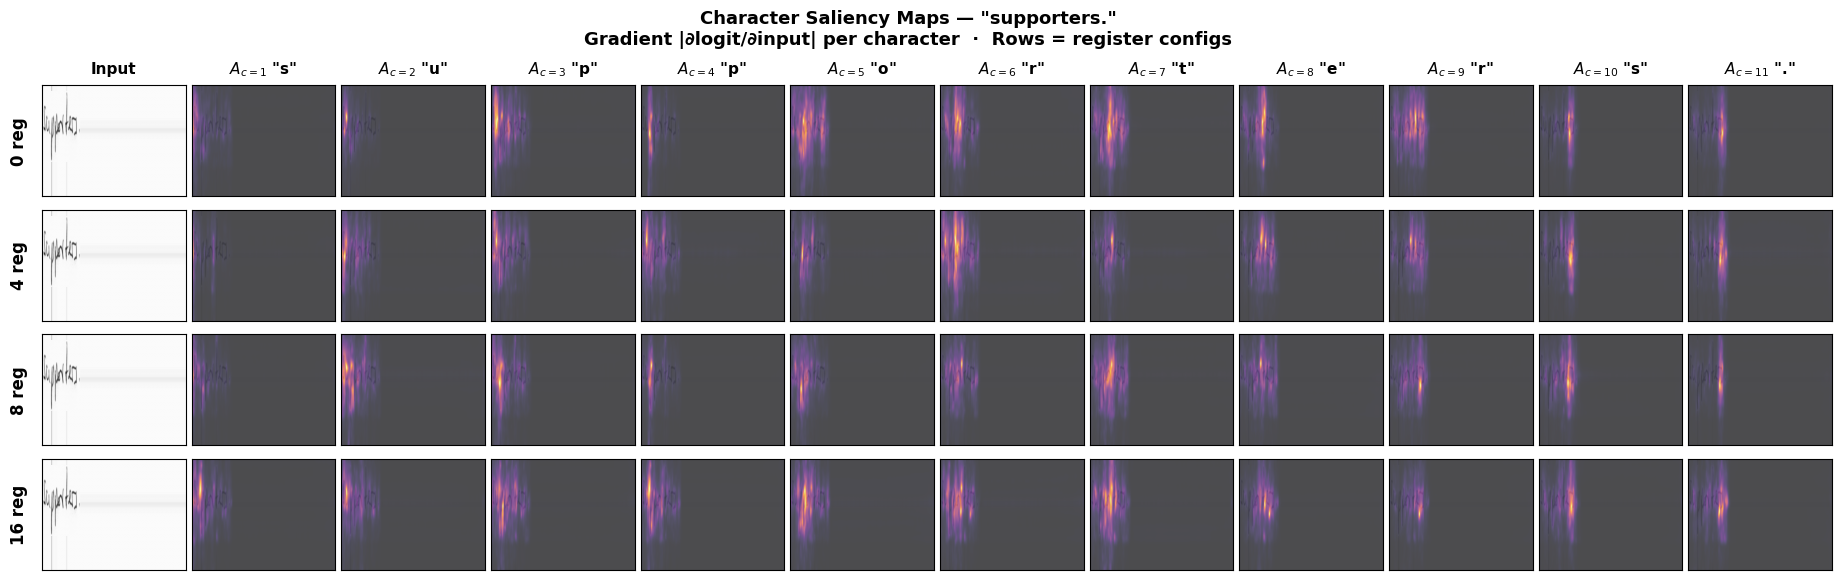

Saved: fig_saliency_supporters.png


In [10]:
# ── Generate Fig 5 style: "supporters." ──
fig = make_char_grid_saliency('a01-091-10.png', 'supporters.', RUNS)
fig.savefig(str(OUT_DIR / 'fig_saliency_supporters.png'), dpi=200, bbox_inches='tight')
fig.savefig(str(OUT_DIR / 'fig_saliency_supporters.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved: fig_saliency_supporters.png')

## Approach 2: Self-Attention (1D→2D) — Corrected Crop

Same grid style but using the self-attention from the ViT transformer.  
For each character's CTC peak, we extract its attention row from the last layer.

In [5]:
def make_char_grid_attention(img_name, gt, register_configs):
    """
    Paper Fig 5 style grid using self-attention.
    For each character, shows which patches that character's token attends to.
    1D attention is broadcast to 2D via the original patch positions.
    """
    tensor, img_proc = prep_image(ROOT / 'notebook' / 'sample_images' / img_name)
    img_crop, (y0, y1, x0, x1) = tight_crop(img_proc, pad=15)
    
    # Patch-to-pixel mapping
    scale = IMG_W / 128  # each patch = ~8 px wide
    p_left = max(0, int(x0 / scale))
    p_right = min(128, int(np.ceil(x1 / scale)))
    
    # Get ref text
    first_nr = sorted(register_configs.keys())[0]
    mdl0 = load_model(register_configs[first_nr])
    with torch.no_grad():
        lg0, _, am0, _, _ = mdl0.forward_explain(tensor)
    ref_text, _ = ctc_decode(lg0)
    del mdl0
    
    n_chars = len(ref_text)
    n_cols = n_chars + 1
    n_rows = len(register_configs)
    
    cell_w = max(1.8, 10.0 / n_cols)
    cell_h = cell_w * img_crop.shape[0] / img_crop.shape[1]
    cell_h = max(cell_h, 1.2)
    
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(cell_w * n_cols + 1.5, cell_h * n_rows + 1.5))
    if n_rows == 1: axes = axes[np.newaxis, :]
    
    for row, (nr, rid) in enumerate(sorted(register_configs.items())):
        model = load_model(rid)
        with torch.no_grad():
            logits, _, attn_maps, _, (_, Wp) = model.forward_explain(tensor)
        R = model.backbone.num_registers
        text, peaks = ctc_decode(logits)
        del model
        
        attn_avg = attn_maps[-1][0].mean(dim=0).numpy()  # [S, S]
        
        # Col 0: input
        ax = axes[row, 0]
        ax.imshow(img_crop, cmap='gray_r', aspect='auto')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_ylabel(f'{nr} reg', fontsize=12, fontweight='bold', labelpad=10)
        if row == 0:
            ax.set_title('Input', fontsize=11, fontweight='bold', pad=8)
        
        for ci in range(n_chars):
            ax = axes[row, ci + 1]
            
            if ci < len(peaks) and ci < len(text):
                t = peaks[ci]
                qi = R + t
                
                # Attention from this character to all patches, cropped
                char_attn = attn_avg[qi, R:]  # [Wp]
                attn_crop = char_attn[p_left:p_right]
                
                # Normalize
                a = attn_crop - attn_crop.min()
                if a.max() > 0: a = a / a.max()
                
                # Upscale to cropped image width and broadcast to 2D
                attn_2d_row = zoom(a, img_crop.shape[1] / len(a), order=1)[:img_crop.shape[1]]
                attn_2d = np.tile(attn_2d_row, (img_crop.shape[0], 1))
                
                ax.imshow(img_crop, cmap='gray_r', aspect='auto', alpha=0.3)
                ax.imshow(attn_2d, cmap='inferno', aspect='auto', alpha=0.7, vmin=0, vmax=1)
            else:
                ax.imshow(np.zeros_like(img_crop), cmap='gray', aspect='auto')
            
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ch_label = ref_text[ci] if ci < len(ref_text) else ''
                ax.set_title(f'$A_{{c={ci+1}}}$ "{ch_label}"', fontsize=11, fontweight='bold', pad=8)
        
        print(f'  {nr:>2} reg: "{text}"')
    
    fig.suptitle(f'Character Self-Attention Maps — "{gt}"\n'
                 f'Self-attention at CTC peak per character  ·  Rows = register configs',
                 fontsize=13, fontweight='bold', y=1.0)
    plt.subplots_adjust(wspace=0.04, hspace=0.12)
    return fig

print('Attention grid function ready.')

Attention grid function ready.


/home/hpc/iwi5/iwi5369h/HTR-Pipeline/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


   0 reg: "talks."
   4 reg: "talks."
   8 reg: "talks."
  16 reg: "talks."


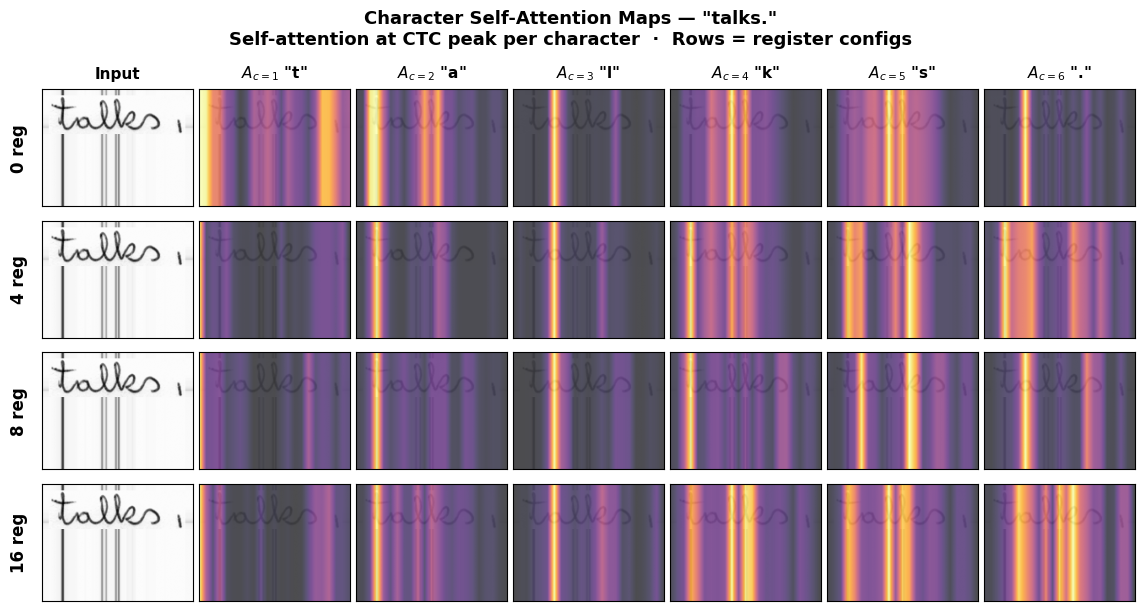

Saved: fig_attn_talks.png


In [11]:
# ── Self-attention version: "talks." ──
fig = make_char_grid_attention('a01-038-12.png', 'talks.', RUNS)
fig.savefig(str(OUT_DIR / 'fig_attn_talks.png'), dpi=200, bbox_inches='tight')
fig.savefig(str(OUT_DIR / 'fig_attn_talks.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved: fig_attn_talks.png')

/home/hpc/iwi5/iwi5369h/HTR-Pipeline/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


   0 reg: "supporters."
   4 reg: "supporters."
   8 reg: "supporters."
  16 reg: "supporters."


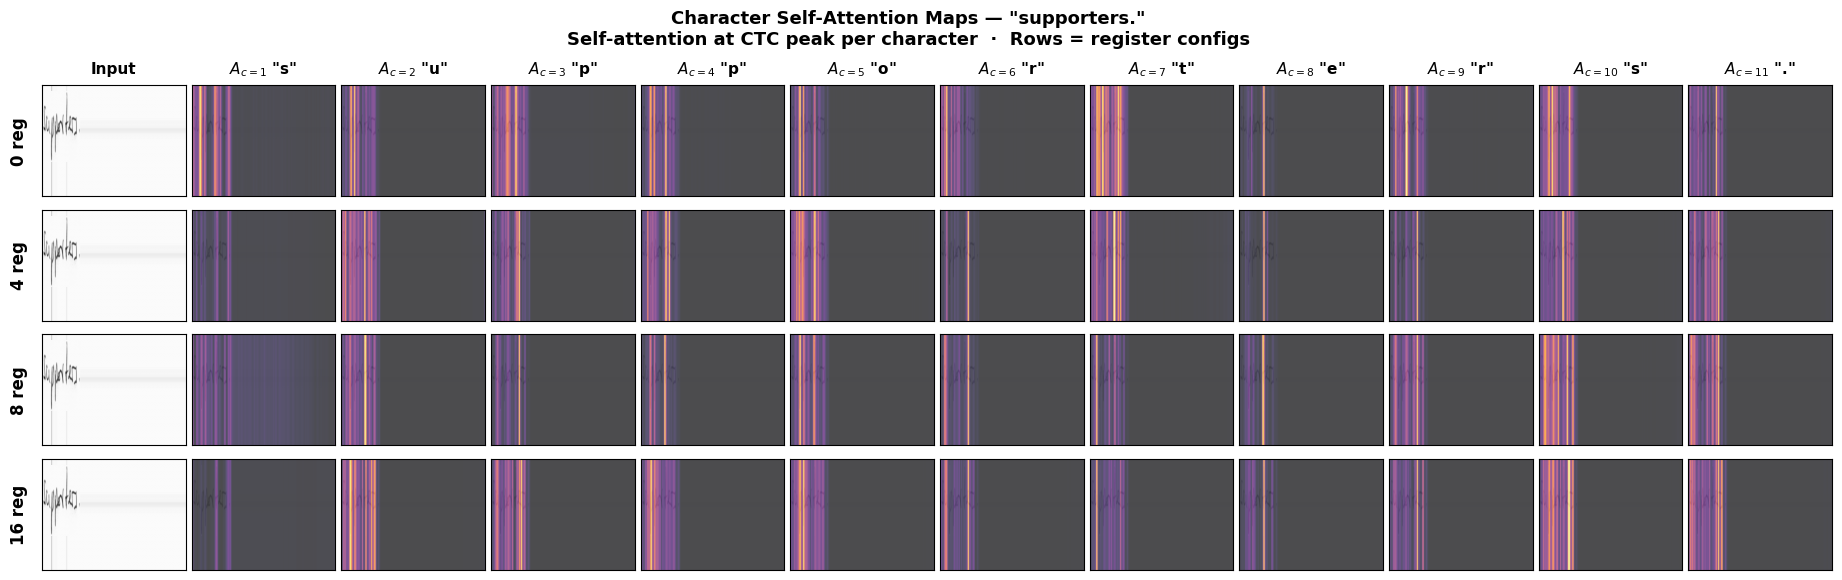

Saved: fig_attn_supporters.png


In [12]:
# ── Self-attention version: "supporters." ──
fig = make_char_grid_attention('a01-091-10.png', 'supporters.', RUNS)
fig.savefig(str(OUT_DIR / 'fig_attn_supporters.png'), dpi=200, bbox_inches='tight')
fig.savefig(str(OUT_DIR / 'fig_attn_supporters.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved: fig_attn_supporters.png')

## Approach 3: Side-by-Side Comparison

Show both methods together for one register config so you can pick the best one.

In [13]:
# ── Side-by-side: Saliency vs Attention for 8 registers ──
img_name = 'a01-038-12.png'
tensor, img_proc = prep_image(ROOT / 'notebook' / 'sample_images' / img_name)
img_crop, (y0, y1, x0, x1) = tight_crop(img_proc, pad=15)

model = load_model('run_63')  # 8 registers
with torch.no_grad():
    logits, _, attn_maps, _, (_, Wp) = model.forward_explain(tensor)
R = model.backbone.num_registers
text, peaks = ctc_decode(logits)
attn_avg = attn_maps[-1][0].mean(dim=0).numpy()

n = len(text)
scale_px = IMG_W / Wp
p_left = max(0, int(x0 / scale_px))
p_right = min(Wp, int(np.ceil(x1 / scale_px)))

fig, axes = plt.subplots(3, n + 1, figsize=(2.0 * (n+1), 6))

# Row 0: Input image
for ci in range(n + 1):
    ax = axes[0, ci]
    ax.imshow(img_crop, cmap='gray_r', aspect='auto')
    ax.set_xticks([]); ax.set_yticks([])
    if ci == 0:
        ax.set_title('Input', fontsize=10, fontweight='bold')
        ax.set_ylabel('Image', fontsize=10, fontweight='bold')
    else:
        ch = text[ci-1] if ci-1 < len(text) else ''
        ax.set_title(f'"{ch}"', fontsize=11, fontweight='bold')

# Row 1: Gradient saliency
axes[1, 0].imshow(img_crop, cmap='gray_r', aspect='auto')
axes[1, 0].set_ylabel('Saliency', fontsize=10, fontweight='bold')
axes[1, 0].set_xticks([]); axes[1, 0].set_yticks([])

for ci in range(n):
    t = peaks[ci]
    class_idx = charset.index(text[ci]) + 1
    sal = compute_char_saliency(model, tensor, t, class_idx)
    sal_crop = sal[y0:y1, x0:x1]
    s_min, s_max = sal_crop.min(), sal_crop.max()
    sal_norm = (sal_crop - s_min) / (s_max - s_min) if s_max > s_min else np.zeros_like(sal_crop)
    
    ax = axes[1, ci + 1]
    ax.imshow(img_crop, cmap='gray_r', aspect='auto', alpha=0.3)
    ax.imshow(sal_norm, cmap='inferno', aspect='auto', alpha=0.7, vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])

# Row 2: Self-attention
axes[2, 0].imshow(img_crop, cmap='gray_r', aspect='auto')
axes[2, 0].set_ylabel('Self-Attn', fontsize=10, fontweight='bold')
axes[2, 0].set_xticks([]); axes[2, 0].set_yticks([])

for ci in range(n):
    t = peaks[ci]
    qi = R + t
    char_attn = attn_avg[qi, R:]
    attn_c = char_attn[p_left:p_right]
    a = attn_c - attn_c.min()
    if a.max() > 0: a = a / a.max()
    attn_row = zoom(a, img_crop.shape[1] / len(a), order=1)[:img_crop.shape[1]]
    attn_2d = np.tile(attn_row, (img_crop.shape[0], 1))
    
    ax = axes[2, ci + 1]
    ax.imshow(img_crop, cmap='gray_r', aspect='auto', alpha=0.3)
    ax.imshow(attn_2d, cmap='inferno', aspect='auto', alpha=0.7, vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])

del model
fig.suptitle(f'Comparison: Gradient Saliency vs Self-Attention — "{text}" (8 registers)',
             fontsize=12, fontweight='bold', y=1.02)
plt.subplots_adjust(wspace=0.04, hspace=0.15)
fig.savefig(str(OUT_DIR / 'fig_comparison_methods.png'), dpi=200, bbox_inches='tight')
fig.savefig(str(OUT_DIR / 'fig_comparison_methods.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved: fig_comparison_methods.png')

/home/hpc/iwi5/iwi5369h/HTR-Pipeline/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


: 

## Summary

| Approach | Type | Pro | Con |
|----------|------|-----|-----|
| **Gradient saliency** | 2D pixel-level | True spatial maps per character, architecture-agnostic | Requires backprop (slower) |
| **Self-attention** | 1D→broadcast 2D | Direct from transformer, fast | Uniform in height (1D patches), less spatially informative |

Both are shown in a clean **Fig 5 style grid**: rows=register configs, columns=character positions.